# Process-based cherry models on the  (winter T × spring T)  plane

Extends the 1-D winter-temperature sensitivity sweep from
`model_exploration.ipynb` to **two dimensions**: every synthetic season
is parameterised by a mean winter temperature *and* a mean spring
temperature, and each process-based model is evaluated on the full grid.

Each panel below is a scatter of `(winter_T, spring_T)` points coloured by
the predicted bloom DOY — a direct view of the model's response surface.

**Models**
- **GDD** — pure forcing, no chilling gate
- **Utah + GDD** — Richardson chill units + forcing
- **ChillingDays + GDD** — simple T ≤ 7.2 °C chill-day proxy + forcing
- **Dynamic + GDD** — Fishman/Luedeling dynamic chill model + forcing

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from tqdm.auto import tqdm

from pysephone.constants import KEY_FEATURES, KEY_OBSERVATIONS_INDEX
from pysephone.models.gdd import GDDModel
from pysephone.models.cf import (
    UtahGDDModel,
    ChillingDaysGDDModel,
    DynamicGDDModel,
)

# ── model ensemble ──────────────────────────────────────────────────────
MODELS = {
    'GDD':              GDDModel(threshold=200.0, t_base=5.0),
    'Utah+GDD':         UtahGDDModel(threshold_c=50.0, threshold_f=200.0, t_base=5.0),
    'ChillingDays+GDD': ChillingDaysGDDModel(threshold_c=50.0, threshold_f=200.0,
                                             t_chill=7.2, t_base=5.0),
    'Dynamic+GDD':      DynamicGDDModel(threshold_c=30.0, threshold_f=200.0,
                                        t_base=5.0, amplitude=5.0),
}

MODEL_COLORS = {
    'GDD':              '#7f8c8d',
    'Utah+GDD':         '#2980b9',
    'ChillingDays+GDD': '#27ae60',
    'Dynamic+GDD':      '#8e44ad',
}

SEASON_START = np.datetime64('2000-10-01')
SEASON_LEN   = 365

## 1. Synthetic season generator

Piecewise-linear annual cycle with four anchor points
(early winter, late winter, spring, summer) plus Gaussian noise.
Winter and spring means are free parameters; summer is held constant.

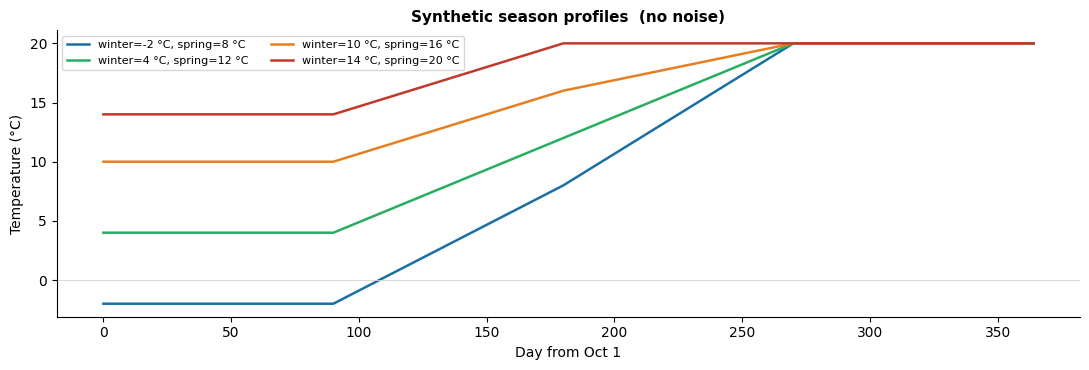

In [2]:
def make_season(
    mean_winter: float = 4.0,
    mean_spring: float = 12.0,
    mean_summer: float = 20.0,
    noise_std:   float = 2.0,
    n_days:      int   = SEASON_LEN,
    seed:        int   = 0,
) -> np.ndarray:
    """365-day synthetic temperature series starting Oct 1.

    Anchor points (DOY from Oct 1): 0 early-winter, 90 mid-winter,
    180 spring, 270 summer, 365 summer — linearly interpolated.
    """
    rng = np.random.default_rng(seed)
    anchors = [
        (0,   mean_winter),
        (90,  mean_winter),
        (180, mean_spring),
        (270, mean_summer),
        (365, mean_summer),
    ]
    days = np.arange(n_days)
    ts = np.zeros(n_days)
    for (d1, t1), (d2, t2) in zip(anchors[:-1], anchors[1:]):
        m = (days >= d1) & (days < d2)
        frac = (days[m] - d1) / (d2 - d1)
        ts[m] = t1 + frac * (t2 - t1)
    ts += rng.normal(0, noise_std, n_days)
    return ts.astype(np.float32)


def make_sample(mean_winter: float, mean_spring: float, seed: int = 0) -> dict:
    return {
        KEY_FEATURES: {'temperature_2m_mean': make_season(
            mean_winter=mean_winter, mean_spring=mean_spring, seed=seed)},
        KEY_OBSERVATIONS_INDEX: {},
        'season_start': SEASON_START,
        'observations': {},
    }


# ── preview: a few scenarios ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.8))
for mw, ms, color in [(-2, 8, '#1a6fa5'), (4, 12, '#27ae60'),
                       (10, 16, '#e67e22'), (14, 20, '#c0392b')]:
    ts = make_season(mean_winter=mw, mean_spring=ms, noise_std=0)
    ax.plot(np.arange(SEASON_LEN), ts, lw=1.8, color=color,
            label=f'winter={mw} °C, spring={ms} °C')
ax.axhline(0, color='lightgrey', lw=0.6)
ax.set_xlabel('Day from Oct 1'); ax.set_ylabel('Temperature (°C)')
ax.set_title('Synthetic season profiles  (no noise)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2. Evaluate every model on the (winter T × spring T) grid

For each `(mean_winter, mean_spring)` cell we run each model on
`N_SEEDS` noise realisations and take the median predicted DOY and
median chilling-fulfilment day.

In [3]:
WINTER_TS  = np.linspace(-4, 16, 25)
SPRING_TS  = np.linspace(4,  24, 25)
N_SEEDS    = 5


def chilling_day(model, sample) -> float:
    """First day on which cumulative chill units meet threshold_c.

    Returns NaN for the GDD model (no chilling gate) or if the threshold
    is never met in the season window.
    """
    get_cf = getattr(model, 'get_cf_features', None)
    if get_cf is None:
        return np.nan
    cs, _ = get_cf(sample)
    cs_sum = cs.cumsum()
    met = np.where(cs_sum >= model.threshold_c)[0]
    return float(met[0]) if met.size else np.nan


# Results containers: {model_name: (n_spring, n_winter) median arrays}
bloom = {name: np.full((len(SPRING_TS), len(WINTER_TS)), np.nan) for name in MODELS}
chill = {name: np.full((len(SPRING_TS), len(WINTER_TS)), np.nan) for name in MODELS}
met   = {name: np.full((len(SPRING_TS), len(WINTER_TS)), False, dtype=bool) for name in MODELS}

total_cells = len(WINTER_TS) * len(SPRING_TS)
pbar = tqdm(total=total_cells, desc='Evaluating grid')

for i, mw in enumerate(WINTER_TS):
    for j, ms in enumerate(SPRING_TS):
        samples = [make_sample(mw, ms, seed=s) for s in range(N_SEEDS)]
        for name, model in MODELS.items():
            bloom_seeds, chill_seeds, met_seeds = [], [], []
            for s in samples:
                _, info = model.predict(s)
                bloom_seeds.append(info['ix'])
                met_seeds.append(bool(info.get('req_met', True)))
                chill_seeds.append(chilling_day(model, s))
            bloom[name][j, i] = np.median(bloom_seeds)
            chill[name][j, i] = np.nanmedian(chill_seeds)
            # A cell is 'met' if the forcing threshold was hit in the majority of seeds
            met[name][j, i]   = sum(met_seeds) > N_SEEDS / 2
        pbar.update(1)
pbar.close()
print('done')

Evaluating grid: 100%|██████████| 625/625 [00:21<00:00, 28.41it/s]

done


## 3. Main figure — predicted bloom DOY on the (winter, spring) plane

One scatter panel per model. Each dot is one grid cell coloured by the
median predicted bloom DOY (across noise seeds). Cells where the forcing
threshold was never met in the season window are marked with a grey `×`
and excluded from the colour scale.

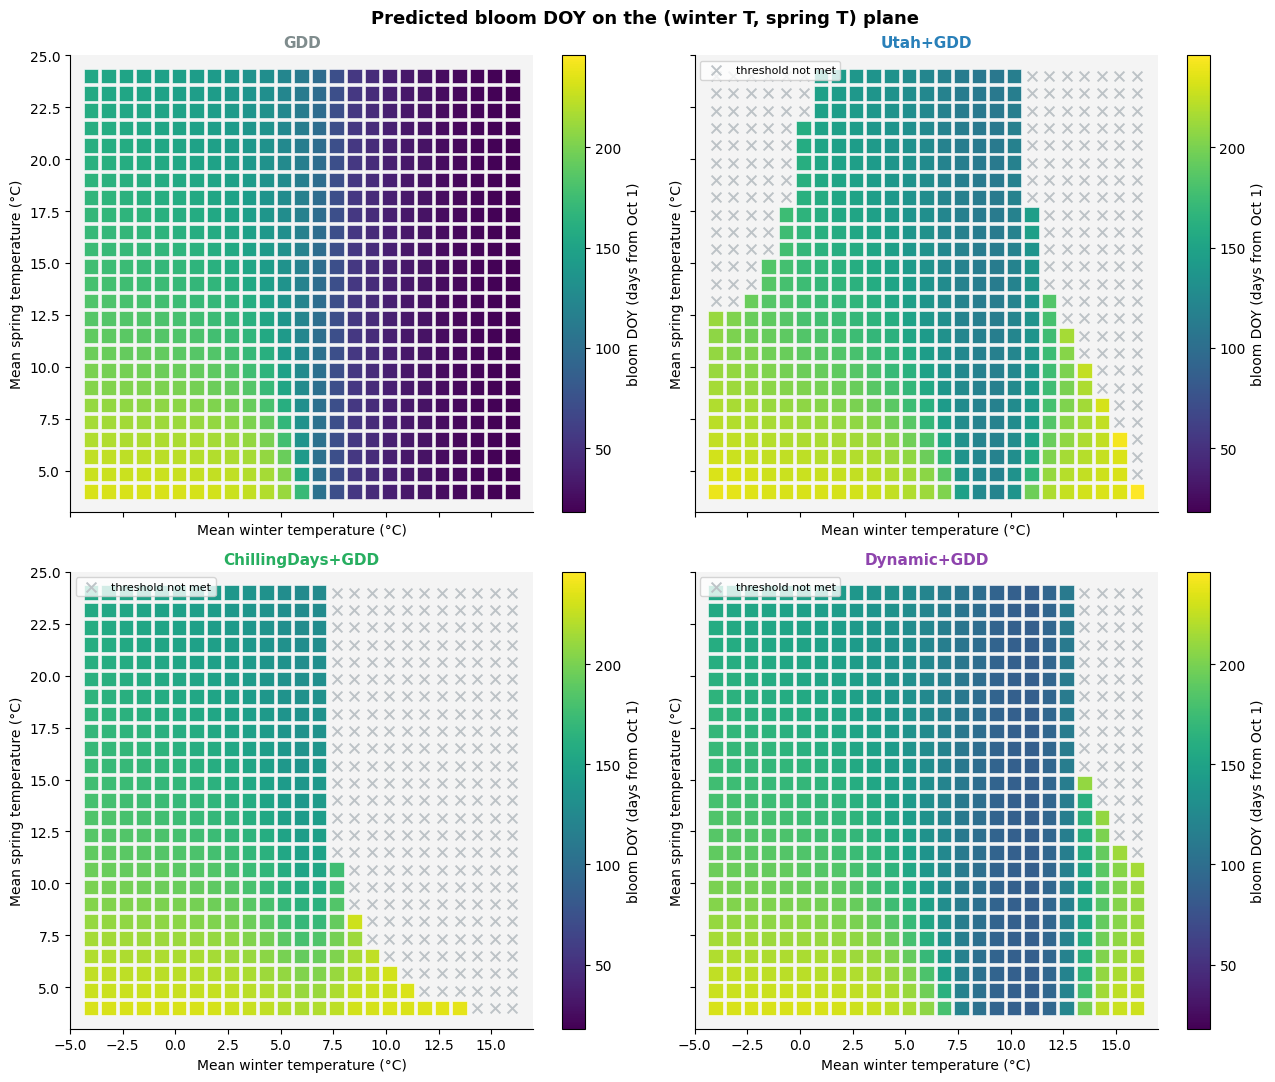

In [4]:
# shared colour scale across panels so they can be compared
all_valid = np.concatenate([b[m].ravel() for b, m in
                            ((bloom[n], met[n]) for n in MODELS)])
valid_finite = all_valid[np.isfinite(all_valid) & (all_valid < SEASON_LEN - 1)]
vmin, vmax = float(valid_finite.min()), float(valid_finite.max())

# mesh of winter/spring values (x = winter, y = spring)
W, S = np.meshgrid(WINTER_TS, SPRING_TS)

fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharex=True, sharey=True)
fig.suptitle('Predicted bloom DOY on the (winter T, spring T) plane',
             fontsize=13, fontweight='bold')

for ax, name in zip(axes.ravel(), MODELS):
    b   = bloom[name]
    mok = met[name] & np.isfinite(b) & (b < SEASON_LEN - 1)

    # scatter valid cells, coloured by DOY
    sc = ax.scatter(W[mok], S[mok], c=b[mok], cmap='viridis',
                    vmin=vmin, vmax=vmax, s=110, marker='s',
                    edgecolors='white', linewidths=0.4)
    # mark cells where the model didn't reach the forcing threshold
    if (~mok).any():
        ax.scatter(W[~mok], S[~mok], c='#bdc3c7', marker='x',
                   s=50, linewidths=1.4, label='threshold not met')
        ax.legend(fontsize=8, loc='upper left')
    plt.colorbar(sc, ax=ax, label='bloom DOY (days from Oct 1)')
    ax.set_title(name, fontsize=11, fontweight='bold',
                 color=MODEL_COLORS[name])
    ax.set_xlabel('Mean winter temperature (°C)')
    ax.set_ylabel('Mean spring temperature (°C)')
    ax.set_facecolor('#f4f4f4')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

## 4. Chilling fulfilment surface  (CF models only)

Same plane, but coloured by the day chilling is completed. This is the
gate that the forcing accumulator waits for — understanding where it falls
out of reach explains the `×` markers in section 3.

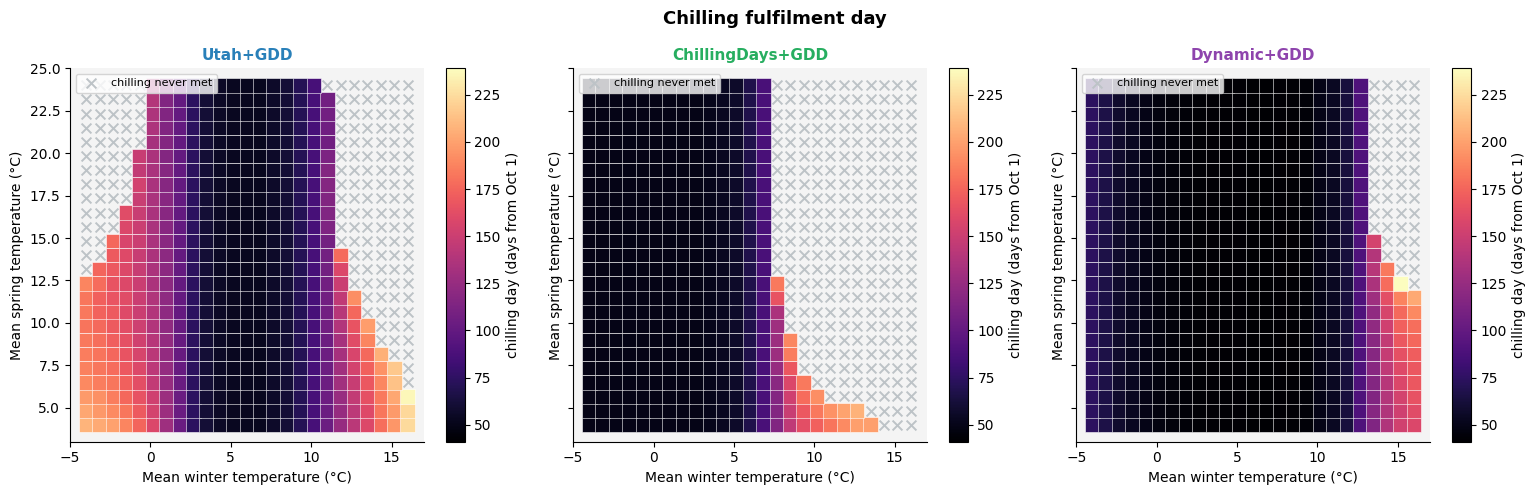

In [5]:
cf_models = [n for n in MODELS if n != 'GDD']

fig, axes = plt.subplots(1, len(cf_models),
                          figsize=(5.2 * len(cf_models), 5), sharex=True, sharey=True)
fig.suptitle('Chilling fulfilment day', fontsize=13, fontweight='bold')

# shared scale for CF models
valid = np.concatenate([chill[n][np.isfinite(chill[n])].ravel() for n in cf_models])
c_vmin, c_vmax = float(valid.min()), float(valid.max())

for ax, name in zip(np.atleast_1d(axes), cf_models):
    c = chill[name]
    ok = np.isfinite(c)
    sc = ax.scatter(W[ok], S[ok], c=c[ok], cmap='magma',
                    vmin=c_vmin, vmax=c_vmax, s=110, marker='s',
                    edgecolors='white', linewidths=0.4)
    if (~ok).any():
        ax.scatter(W[~ok], S[~ok], c='#bdc3c7', marker='x',
                   s=50, linewidths=1.4, label='chilling never met')
        ax.legend(fontsize=8, loc='upper left')
    plt.colorbar(sc, ax=ax, label='chilling day (days from Oct 1)')
    ax.set_title(name, fontsize=11, fontweight='bold', color=MODEL_COLORS[name])
    ax.set_xlabel('Mean winter temperature (°C)')
    ax.set_ylabel('Mean spring temperature (°C)')
    ax.set_facecolor('#f4f4f4')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

## 5. Difference from pure GDD  (what the chilling gate costs)

`Δ DOY = (CF model bloom) − (GDD bloom)` on the same grid. Positive values
(warm colours) mean the chilling gate **delayed** bloom relative to pure
forcing; zero means the gate was inconsequential in that part of the plane.

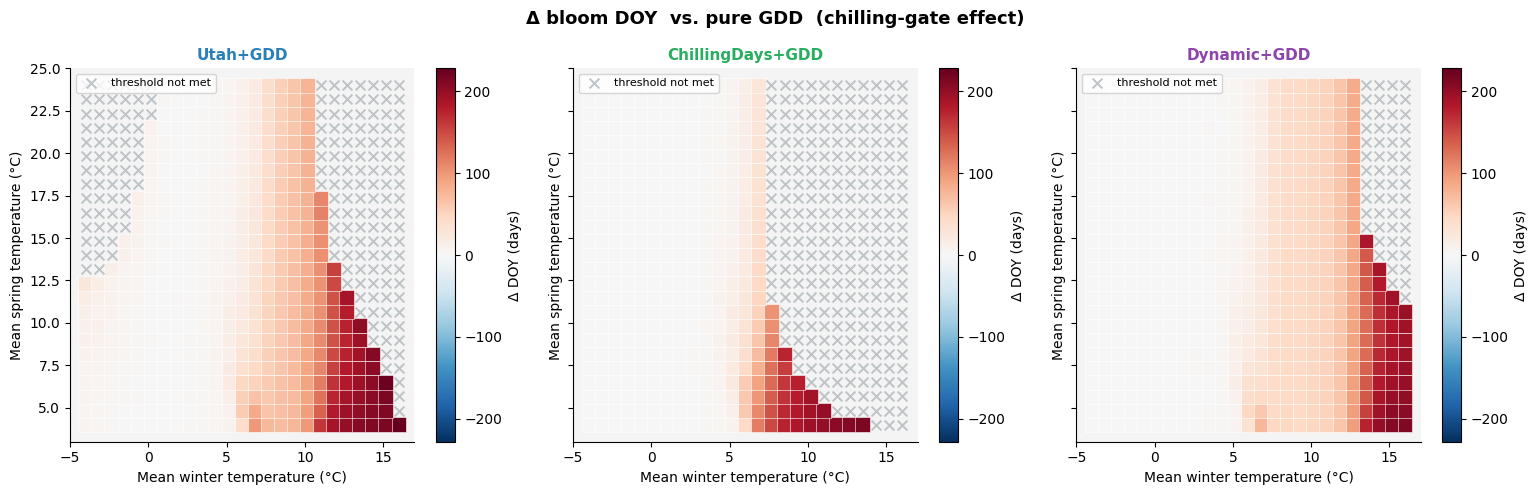

In [6]:
base = bloom['GDD']

# use a symmetric divergent colormap centred on 0
diffs = {n: bloom[n] - base for n in cf_models}
dmax = max(np.nanmax(np.abs(d[met[n]])) for n, d in diffs.items() if np.any(met[n]))

fig, axes = plt.subplots(1, len(cf_models),
                          figsize=(5.2 * len(cf_models), 5), sharex=True, sharey=True)
fig.suptitle('Δ bloom DOY  vs. pure GDD  (chilling-gate effect)',
             fontsize=13, fontweight='bold')

for ax, name in zip(np.atleast_1d(axes), cf_models):
    d  = diffs[name]
    ok = met[name] & np.isfinite(d) & (bloom[name] < SEASON_LEN - 1)
    sc = ax.scatter(W[ok], S[ok], c=d[ok], cmap='RdBu_r',
                    vmin=-dmax, vmax=dmax, s=110, marker='s',
                    edgecolors='white', linewidths=0.4)
    if (~ok).any():
        ax.scatter(W[~ok], S[~ok], c='#bdc3c7', marker='x',
                   s=50, linewidths=1.4, label='threshold not met')
        ax.legend(fontsize=8, loc='upper left')
    plt.colorbar(sc, ax=ax, label='Δ DOY (days)')
    ax.set_title(name, fontsize=11, fontweight='bold', color=MODEL_COLORS[name])
    ax.set_xlabel('Mean winter temperature (°C)')
    ax.set_ylabel('Mean spring temperature (°C)')
    ax.set_facecolor('#f4f4f4')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

## 6. 1-D slices through the surface

Vary winter at a few fixed spring temperatures (left) and vary spring at
a few fixed winter temperatures (right) to see how each axis acts on its
own — a direct analogue of the 1-D figure that motivated this notebook.

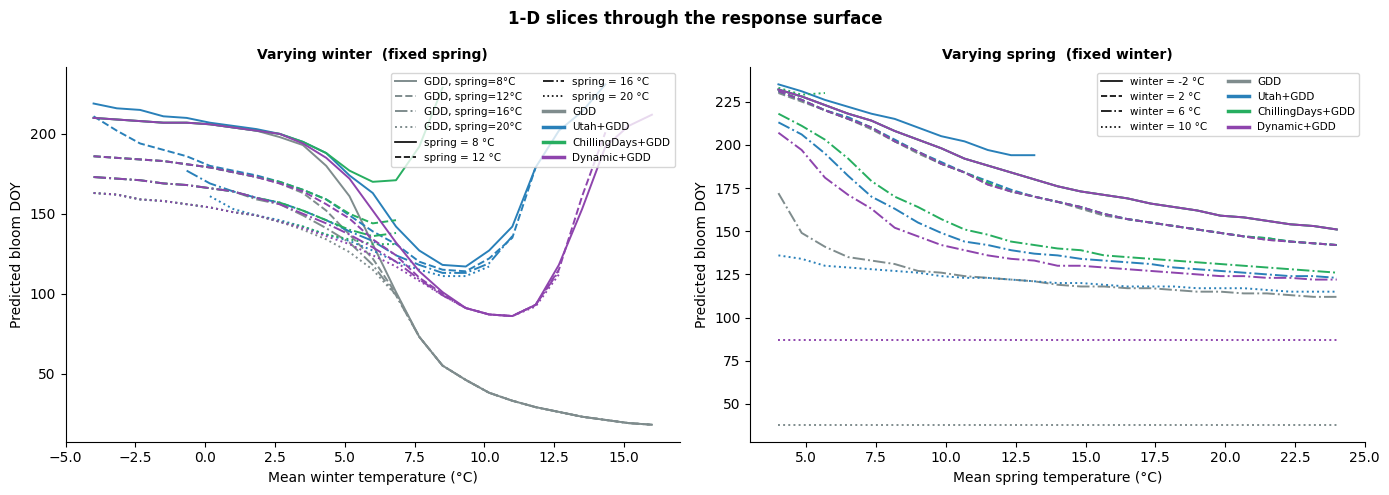

In [7]:
def _slice_idx(values, target):
    return int(np.argmin(np.abs(values - target)))

SPRING_FIXED_TARGETS = [8.0, 12.0, 16.0, 20.0]
WINTER_FIXED_TARGETS = [-2.0, 2.0, 6.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1-D slices through the response surface',
             fontsize=12, fontweight='bold')

# Left: vs winter, lines per fixed spring
ax = axes[0]
line_styles = ['-', '--', '-.', ':']
for name in MODELS:
    for ls, target in zip(line_styles, SPRING_FIXED_TARGETS):
        j = _slice_idx(SPRING_TS, target)
        row = bloom[name][j, :].copy()
        row[~met[name][j, :]] = np.nan
        ax.plot(WINTER_TS, row, color=MODEL_COLORS[name], lw=1.4, ls=ls,
                label=f'{name}, spring={target:.0f}°C' if name == 'GDD' else None)
# Legend labels: one per spring target
for ls, target in zip(line_styles, SPRING_FIXED_TARGETS):
    ax.plot([], [], color='black', lw=1.2, ls=ls, label=f'spring = {target:.0f} °C')
for name, color in MODEL_COLORS.items():
    ax.plot([], [], color=color, lw=2.5, label=name)
ax.set_xlabel('Mean winter temperature (°C)')
ax.set_ylabel('Predicted bloom DOY')
ax.set_title('Varying winter  (fixed spring)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5, ncol=2, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: vs spring, lines per fixed winter
ax = axes[1]
for name in MODELS:
    for ls, target in zip(line_styles, WINTER_FIXED_TARGETS):
        i = _slice_idx(WINTER_TS, target)
        col = bloom[name][:, i].copy()
        col[~met[name][:, i]] = np.nan
        ax.plot(SPRING_TS, col, color=MODEL_COLORS[name], lw=1.4, ls=ls)
for ls, target in zip(line_styles, WINTER_FIXED_TARGETS):
    ax.plot([], [], color='black', lw=1.2, ls=ls, label=f'winter = {target:.0f} °C')
for name, color in MODEL_COLORS.items():
    ax.plot([], [], color=color, lw=2.5, label=name)
ax.set_xlabel('Mean spring temperature (°C)')
ax.set_ylabel('Predicted bloom DOY')
ax.set_title('Varying spring  (fixed winter)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5, ncol=2, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

## 7. Data-driven LSTM trained on GMU Japan yedoensis

Load `GMU_Cherry_Japan_Y` (yedoensis-only subset, target `gmu_0`), download the
daily ERA5 temperature series, and train a 2-layer LSTM with temperature as
its only input.  We then run the trained network on **exactly the same
synthetic grid** used for the process-based models so the response surfaces
are directly comparable.

In [ ]:
import torch

from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.models.lstm import LSTMModel

LSTM_DATASET_KEY = 'GMU_Cherry_Japan_Y'
LSTM_OBS_KEY     = 'gmu_0'
LSTM_CUTOFF_YEAR = 2010
LSTM_DATA_KEYS   = ['temperature_2m_mean']

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

cal    = Calendar(default_start='10-01', default_length=365)
_cache = FeatureCache.load(FeatureCache.default_path(LSTM_DATASET_KEY, LSTM_DATA_KEYS))
ds     = Dataset.load(LSTM_DATASET_KEY, calendar=cal, feature_providers=[_cache])

# Drop any locations whose index is absent from the cache
bad_locs = set()
for ix in ds.iter_index():
    try:
        _cache.get_data(ix)
    except KeyError:
        bad_locs.add((ix[0], ix[1]))

if bad_locs:
    print(f'Dropping {len(bad_locs)} location(s) with missing cache data:')
    for loc in sorted(bad_locs):
        print(f'  {loc}')
    ds = ds.select_locations([loc for loc in ds.locations if loc not in bad_locs])
else:
    print('All features present.')

target_fn = lambda s: s['observations'][LSTM_OBS_KEY]
years_trn = [y for y in ds.years if y <  LSTM_CUTOFF_YEAR]
years_val = [y for y in ds.years if y >= LSTM_CUTOFF_YEAR]
ds_trn = ds.select_years(years_trn)
ds_val = ds.select_years(years_val)
print(f'LSTM train {len(ds_trn)} samples  |  val {len(ds_val)} samples')


In [9]:
lstm, fit_info = LSTMModel.fit(
    target_fn       = target_fn,
    dataset         = ds_trn,
    model_kwargs    = dict(
        data_keys   = LSTM_DATA_KEYS,
        hidden_size = 64,
        num_layers  = 2,
    ),
    num_epochs               = 60,
    batch_size               = 32,
    val_period               = 5,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 20,
    scheduler_decay          = 0.5,
    early_stopping           = True,
    early_stopping_patience  = 8,
    early_stopping_min_delta = 1e-3,
    device                   = DEVICE,
    seed                     = 0,
    verbose                  = True,
)
lstm.eval()
print('LSTM training complete.')

LSTMModel epoch [    1/60] lr=1.00e-03 loss=0.62619: 100%|██████████| 36/36 [00:02<00:00, 13.39it/s]
LSTMModel epoch [    2/60] lr=1.00e-03 loss=0.30113: 100%|██████████| 36/36 [00:02<00:00, 13.41it/s]
LSTMModel epoch [    3/60] lr=1.00e-03 loss=0.08321: 100%|██████████| 36/36 [00:02<00:00, 13.14it/s]
LSTMModel epoch [    4/60] lr=1.00e-03 loss=0.08192: 100%|██████████| 36/36 [00:02<00:00, 13.22it/s]
LSTMModel epoch [    5/60] lr=1.00e-03 loss=0.12346: 100%|██████████| 36/36 [00:02<00:00, 13.41it/s]
LSTMModel val loss=0.13945: 100%|██████████| 12/12 [00:00<00:00, 68.90it/s]
LSTMModel epoch [    6/60] lr=1.00e-03 loss=0.11834: 100%|██████████| 36/36 [00:02<00:00, 13.45it/s]
LSTMModel epoch [    7/60] lr=1.00e-03 loss=0.06196: 100%|██████████| 36/36 [00:02<00:00, 13.77it/s]
LSTMModel epoch [    8/60] lr=1.00e-03 loss=0.05813: 100%|██████████| 36/36 [00:02<00:00, 12.89it/s]
LSTMModel epoch [    9/60] lr=1.00e-03 loss=0.05996: 100%|██████████| 36/36 [00:02<00:00, 13.28it/s]
LSTMModel epoch

LSTM training complete.


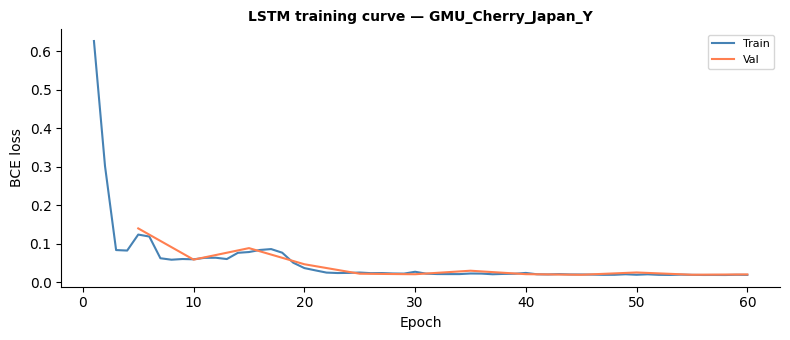

In [10]:
# ── training curve ──────────────────────────────────────────────────────
epochs   = [e['epoch']            for e in fit_info['epochs']]
trn_loss = [e['loss']             for e in fit_info['epochs']]
val_ep   = [e['epoch']            for e in fit_info['epochs'] if 'val' in e]
val_loss = [e['val']['loss']      for e in fit_info['epochs'] if 'val' in e]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(epochs, trn_loss, color='steelblue', lw=1.5, label='Train')
if val_loss:
    ax.plot(val_ep, val_loss, color='coral', lw=1.5, label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE loss')
ax.set_title(f'LSTM training curve — {LSTM_DATASET_KEY}', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 8. LSTM sensitivity on the (winter T × spring T) plane

Run the trained LSTM on every cell of the same grid, batched through the
network in a single forward pass for speed.

**Note.** The LSTM has *no explicit chilling gate*, so it returns a bloom
prediction in every cell — including combinations of winter and spring
temperatures that the CF models declared impossible. That's itself an
interesting thing to compare.

In [11]:
@torch.no_grad()
def lstm_grid_predict(model, winter_ts, spring_ts, n_seeds=N_SEEDS):
    """Return a (n_spring, n_winter) array of median LSTM predicted DOYs."""
    batch_samples = []
    for s in range(n_seeds):
        for i, mw in enumerate(winter_ts):
            for j, ms in enumerate(spring_ts):
                batch_samples.append(make_sample(mw, ms, seed=s))

    tensors = [LSTMModel.cast_to_tensor(s, device=DEVICE) for s in batch_samples]
    batch   = LSTMModel.collate_fn(tensors)

    ixs, _ = model(batch)
    ixs = ixs.detach().cpu().numpy()

    arr = ixs.reshape(n_seeds, len(winter_ts), len(spring_ts))
    return np.median(arr, axis=0).T   # (n_spring, n_winter)


lstm_bloom = lstm_grid_predict(lstm, WINTER_TS, SPRING_TS, n_seeds=N_SEEDS)
print('LSTM grid shape:', lstm_bloom.shape,
      '  range:', f'{lstm_bloom.min():.0f}–{lstm_bloom.max():.0f}')

LSTM grid shape: (25, 25)   range: 83–211


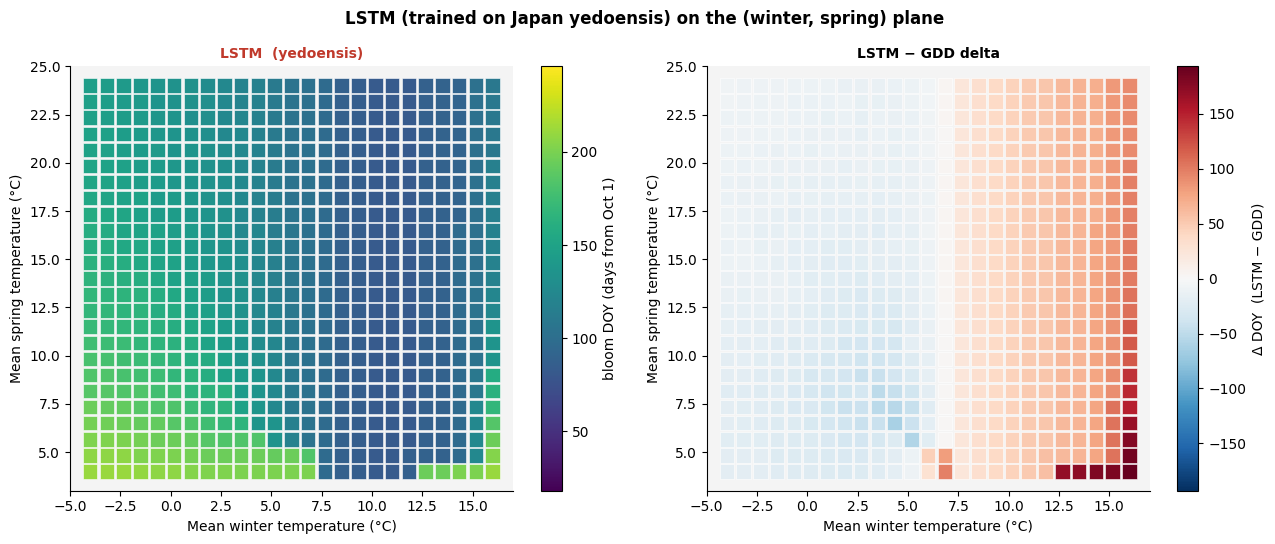

In [12]:
# ── LSTM surface + delta-vs-GDD ─────────────────────────────────────────
lstm_finite = lstm_bloom[np.isfinite(lstm_bloom) & (lstm_bloom < SEASON_LEN - 1)]
c_min = float(min(vmin, lstm_finite.min()))
c_max = float(max(vmax, lstm_finite.max()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('LSTM (trained on Japan yedoensis) on the (winter, spring) plane',
             fontsize=12, fontweight='bold')

# Left: LSTM surface
ax = axes[0]
mok = np.isfinite(lstm_bloom) & (lstm_bloom < SEASON_LEN - 1)
sc = ax.scatter(W[mok], S[mok], c=lstm_bloom[mok], cmap='viridis',
                vmin=c_min, vmax=c_max, s=110, marker='s',
                edgecolors='white', linewidths=0.4)
plt.colorbar(sc, ax=ax, label='bloom DOY (days from Oct 1)')
ax.set_title('LSTM  (yedoensis)', fontsize=10, fontweight='bold', color='#c0392b')
ax.set_xlabel('Mean winter temperature (°C)')
ax.set_ylabel('Mean spring temperature (°C)')
ax.set_facecolor('#f4f4f4')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: LSTM − GDD delta
gdd_bloom = bloom['GDD']
delta = lstm_bloom - gdd_bloom
ok = np.isfinite(delta) & met['GDD'] & mok
dmax = float(np.nanmax(np.abs(delta[ok]))) if ok.any() else 30.0
ax = axes[1]
sc = ax.scatter(W[ok], S[ok], c=delta[ok], cmap='RdBu_r',
                vmin=-dmax, vmax=dmax, s=110, marker='s',
                edgecolors='white', linewidths=0.4)
plt.colorbar(sc, ax=ax, label='Δ DOY  (LSTM − GDD)')
ax.set_title('LSTM − GDD delta', fontsize=10, fontweight='bold')
ax.set_xlabel('Mean winter temperature (°C)')
ax.set_ylabel('Mean spring temperature (°C)')
ax.set_facecolor('#f4f4f4')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()

### 8b. LSTM on the 1-D slices (direct comparison with §6)

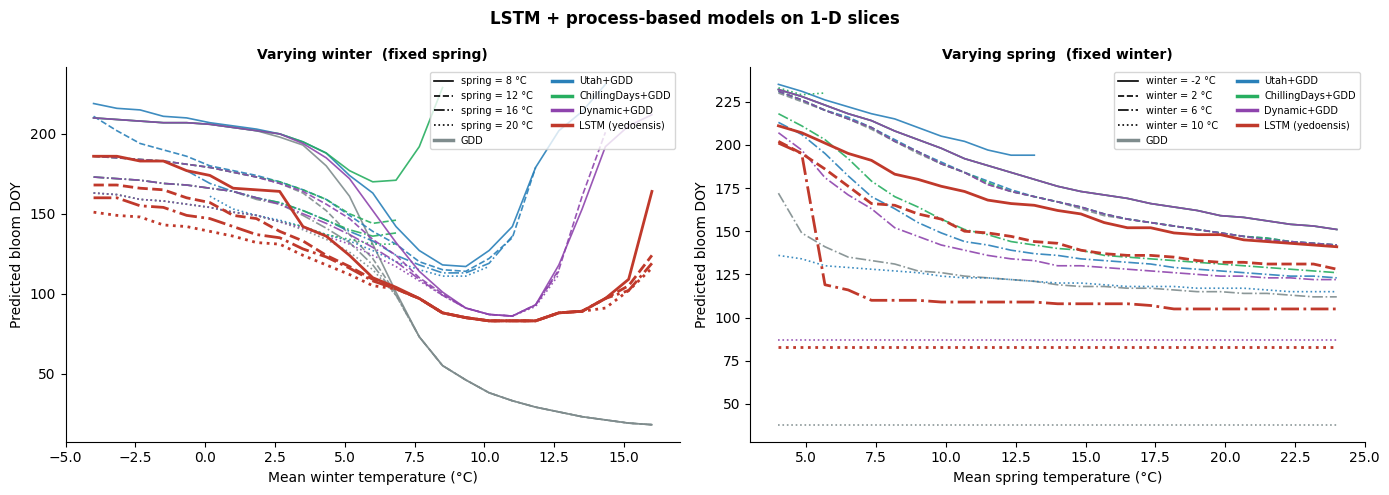

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM + process-based models on 1-D slices',
             fontsize=12, fontweight='bold')

LSTM_COLOR = '#c0392b'
line_styles = ['-', '--', '-.', ':']

# Left: vs winter, fixed spring
ax = axes[0]
for name in MODELS:
    for ls, target in zip(line_styles, SPRING_FIXED_TARGETS):
        j = _slice_idx(SPRING_TS, target)
        row = bloom[name][j, :].copy()
        row[~met[name][j, :]] = np.nan
        ax.plot(WINTER_TS, row, color=MODEL_COLORS[name], lw=1.2, ls=ls, alpha=0.9)
for ls, target in zip(line_styles, SPRING_FIXED_TARGETS):
    j = _slice_idx(SPRING_TS, target)
    ax.plot(WINTER_TS, lstm_bloom[j, :], color=LSTM_COLOR, lw=2.0, ls=ls)
for ls, target in zip(line_styles, SPRING_FIXED_TARGETS):
    ax.plot([], [], color='black', lw=1.2, ls=ls, label=f'spring = {target:.0f} °C')
for name, color in {**MODEL_COLORS, 'LSTM (yedoensis)': LSTM_COLOR}.items():
    ax.plot([], [], color=color, lw=2.5, label=name)
ax.set_xlabel('Mean winter temperature (°C)'); ax.set_ylabel('Predicted bloom DOY')
ax.set_title('Varying winter  (fixed spring)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: vs spring, fixed winter
ax = axes[1]
for name in MODELS:
    for ls, target in zip(line_styles, WINTER_FIXED_TARGETS):
        i = _slice_idx(WINTER_TS, target)
        col = bloom[name][:, i].copy()
        col[~met[name][:, i]] = np.nan
        ax.plot(SPRING_TS, col, color=MODEL_COLORS[name], lw=1.2, ls=ls, alpha=0.9)
for ls, target in zip(line_styles, WINTER_FIXED_TARGETS):
    i = _slice_idx(WINTER_TS, target)
    ax.plot(SPRING_TS, lstm_bloom[:, i], color=LSTM_COLOR, lw=2.0, ls=ls)
for ls, target in zip(line_styles, WINTER_FIXED_TARGETS):
    ax.plot([], [], color='black', lw=1.2, ls=ls, label=f'winter = {target:.0f} °C')
for name, color in {**MODEL_COLORS, 'LSTM (yedoensis)': LSTM_COLOR}.items():
    ax.plot([], [], color=color, lw=2.5, label=name)
ax.set_xlabel('Mean spring temperature (°C)'); ax.set_ylabel('Predicted bloom DOY')
ax.set_title('Varying spring  (fixed winter)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()